# **Providing data-driven suggestions for HR**

## Description and deliverables

We need to analyze a dataset and build predictive models that can provide insights to the Human Resources (HR) department of a large consulting firm.


In our deliverables, we will include the model evaluation (and interpretation if applicable), a data visualization(s) of our choice that is directly related to the question we ask, and ethical considerations.

# **PACE stages**


## **Pace: Plan**

In this stage, we considered the following:

### Understanding the business scenario and problem

The HR department at Salifort Motors wants to take some initiatives to improve employee satisfaction levels at the company. They collected data from employees. We'll help them to provide data-driven suggestions based on my understanding of the data. Let's answer the following question: what's likely to make the employee leave the company?

My goals in this project are to analyze the data collected by the HR department and to build a model that predicts whether or not an employee will leave the company.

If we can predict employees likely to quit, it might be possible to identify factors that contribute to their leaving. Because it is time-consuming and expensive to find, interview, and hire new employees, increasing employee retention will be beneficial to the company.

### Familiarizing myself with the HR dataset

The dataset that I'll be using in this lab contains 15,000 rows and 10 columns for the variables listed below.

For more information about the data, refer to its source on [Kaggle](https://www.kaggle.com/datasets/mfaisalqureshi/hr-analytics-and-job-prediction?select=HR_comma_sep.csv).

Variable  |Description |
-----|-----|
satisfaction_level|Employee-reported job satisfaction level [0&ndash;1]|
last_evaluation|Score of employee's last performance review [0&ndash;1]|
number_project|Number of projects employee contributes to|
average_monthly_hours|Average number of hours employee worked per month|
time_spend_company|How long the employee has been with the company (years)
Work_accident|Whether or not the employee experienced an accident while at work
left|Whether or not the employee left the company
promotion_last_5years|Whether or not the employee was promoted in the last 5 years
Department|The employee's department
salary|The employee's salary (U.S. dollars)

1. Our stakeholders are the HR team with low technical knowledge.
2. I'm trying to predict whether the customer tends to leave the company before they do so.
3. The target variable we're trying to predict would be `left`, and other columns represent important features that seem to have relations with it.
4. The errors in the prediction can cost the company, where false positive errors (where the model predicts the employee will leave while they won't) can cause the company to waste money trying to satisfy an employee who will NOT leave. While false negative errors (where the model predicts an employee won't leave, when they actually will) can cause the company to lose one of its employees. However, if we can develop a model that performs better than a random model, we can still gain a benefit that outweighs these problems by trying to minimize false positive errors.

## Step 1. Imports

*   Importing packages
*   Loading dataset



### Importing packages

In [ ]:
# Importing packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [ ]:
# Running this cell to import our data.

# Loading dataset into a dataframe
df0 = pd.read_csv("HR_capstone_dataset.csv")


# Displaying first few rows of the dataframe
df0.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


## Step 2. Data Exploration (Initial EDA and data cleaning)

- Understanding our variables
- Cleaning our dataset (missing data, redundant data, outliers)

### Gathering basic information about the data

In [ ]:
# Gathering basic information about the data
df0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


### Gathering descriptive statistics about the data

In [ ]:
# Gathering descriptive statistics about the data
df0.describe(include='all')

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999,14999
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,3
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sales,low
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4140,7316
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268,NaN,NaN
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281,NaN,NaN
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000,NaN,NaN
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000,NaN,NaN
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000,NaN,NaN
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000,NaN,NaN


### Renaming columns

As a data cleaning step, we'll rename the columns as needed. We'll standardize the column names so that they are all in `snake_case`, correct any column names that are misspelled, and make column names more concise as needed.

In [ ]:
# Displaying all column names
df0.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='object')

In [ ]:
# Renaming columns as needed
df= df0.rename(columns= {'time_spend_company':'tenure', 'Department':'department', 'Work_accident':'work_accident', 'number_project':'n_projects'})

# Displaying all column names after the update
df.head()

,satisfaction_level,last_evaluation,n_projects,average_montly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


### Checking missing values

Checking for any missing values in the data.

In [ ]:
# Checking for missing values
df.isna().sum()

satisfaction_level       0
last_evaluation          0
n_projects               0
average_montly_hours     0
tenure                   0
work_accident            0
left                     0
promotion_last_5years    0
department               0
salary                   0
dtype: int64

### Checking duplicates

Checking for any duplicate entries in the data.

In [ ]:
# Checking for duplicates
df.duplicated().sum()

3008

In [ ]:
# Inspecting some rows containing duplicates as needed
df[df.duplicated()].head(10)

,satisfaction_level,last_evaluation,n_projects,average_montly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
396,0.46,0.57,2,139,3,0,1,0,sales,low
866,0.41,0.46,2,128,3,0,1,0,accounting,low
1317,0.37,0.51,2,127,3,0,1,0,sales,medium
1368,0.41,0.52,2,132,3,0,1,0,RandD,low
1461,0.42,0.53,2,142,3,0,1,0,sales,low
1516,0.40,0.50,2,127,3,0,1,0,IT,low
1616,0.37,0.46,2,156,3,0,1,0,sales,low
1696,0.39,0.56,2,160,3,0,1,0,sales,low
1833,0.10,0.85,6,266,4,0,1,0,sales,low
12000,0.38,0.53,2,157,3,0,1,0,sales,low


In [ ]:
# Dropping duplicates and saving the resulting dataframe in a new variable as needed
df1 = df.drop_duplicates()
# Displaying first few rows of new dataframe as needed
df1.head()

,satisfaction_level,last_evaluation,n_projects,average_montly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


### Checking outliers

Checking for outliers in the data.

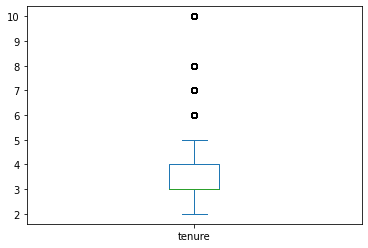

In [ ]:
# Creating a boxplot to visualize distribution of `time_spend_company` and detecting any outliers
df1['tenure'].plot.box()

In [ ]:
# Determining the number of rows containing outliers
df1[df1['tenure']>5]['tenure'].count()

824

Certain types of models are more sensitive to outliers than others. When we get to the stage of building our model, we'll consider whether to remove outliers, based on the type of model we decide to use.

# pAce: Analyze Stage
- Performing EDA (analyzing relationships between variables)

1. The variables have no multicollinearity, while some factors like `average_montly_hours`, `satisfaction_level`, `last_evaluation`, `n_project` and `tenure` have a clear effect on `left`.
2. The classes of the data are not balanced, where only 18% of employees represented in the data actually left, therefore the class distribution is 18/82.
3. We've encoded categorical variables `sales` and `department` so that the model can recognize them and take them into account.
4. It's important to perform EDA to get a sense of the data, how it is formatted, what needs to be changed and fixed, and what type of ML models would best fit the data.
5. We don't have any ethical considerations in this specific stage.

## Step 2. Data Exploration (Continued EDA)

We'll begin by understanding how many employees left and what percentage of all employees this figure represents.

In [ ]:
# Getting numbers of people who left vs. stayed
df1['left'].value_counts()
# Getting percentages of people who left vs. stayed
df1['left'].value_counts(normalize = True)

0    0.833959
1    0.166041
Name: left, dtype: float64

In [ ]:
df1.head()
df1['salary'] = df1['salary'].replace({'low':1, 'medium':2, 'high':3})
df = pd.get_dummies(df1, columns=['department'], drop_first=True,dtype=int)
df.head()

,satisfaction_level,last_evaluation,n_projects,average_montly_hours,tenure,work_accident,left,promotion_last_5years,salary,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.38,0.53,2,157,3,0,1,0,1,0,0,0,0,0,0,1,0,0
1,0.80,0.86,5,262,6,0,1,0,2,0,0,0,0,0,0,1,0,0
2,0.11,0.88,7,272,4,0,1,0,2,0,0,0,0,0,0,1,0,0
3,0.72,0.87,5,223,5,0,1,0,1,0,0,0,0,0,0,1,0,0
4,0.37,0.52,2,159,3,0,1,0,1,0,0,0,0,0,0,1,0,0


### Data visualizations

Now, we'll examine variables that we're interested in, and create plots to visualize relationships between variables in the data.

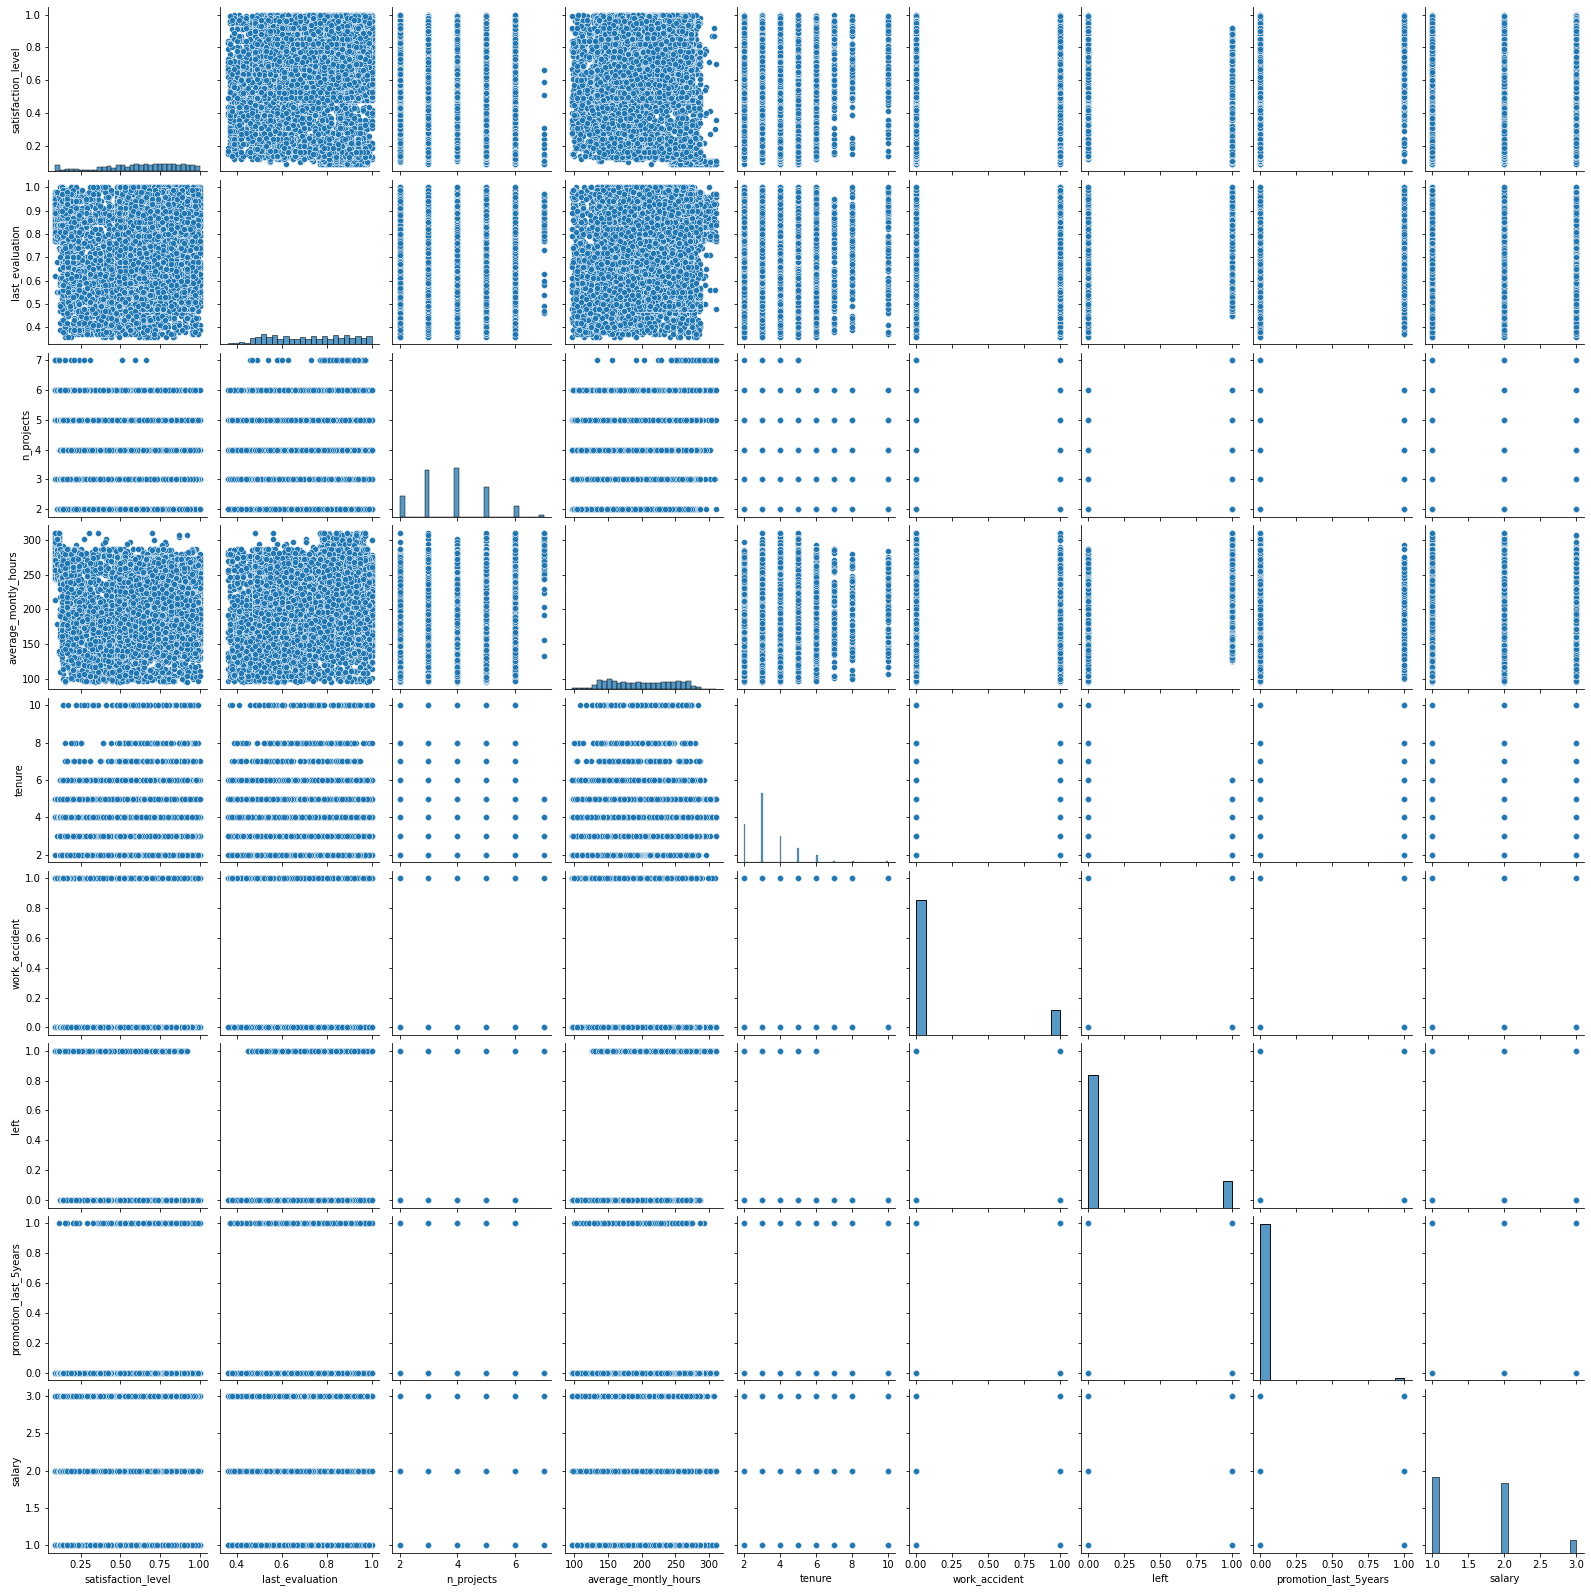

In [ ]:
# Creating a plot as needed
sns.pairplot(df1)

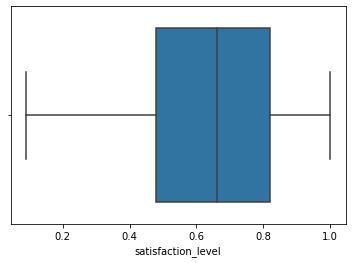

In [ ]:
# Creating a plot as needed
sns.boxplot(data=df1, x='satisfaction_level')

In [ ]:
# Creating a plot as needed
df1.head()

,satisfaction_level,last_evaluation,n_projects,average_montly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,1
1,0.80,0.86,5,262,6,0,1,0,sales,2
2,0.11,0.88,7,272,4,0,1,0,sales,2
3,0.72,0.87,5,223,5,0,1,0,sales,1
4,0.37,0.52,2,159,3,0,1,0,sales,1


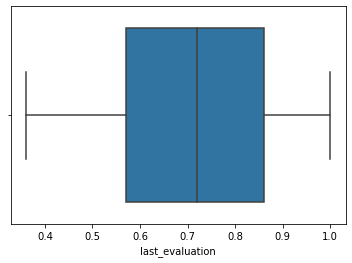

In [ ]:
# Creating a plot as needed
sns.boxplot(data=df1, x='last_evaluation')

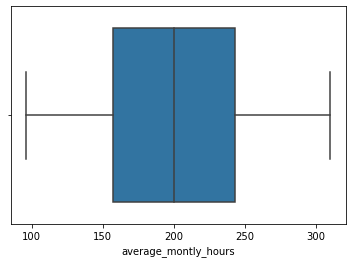

In [ ]:
# Creating a plot as needed
sns.boxplot(data=df1, x='average_montly_hours')

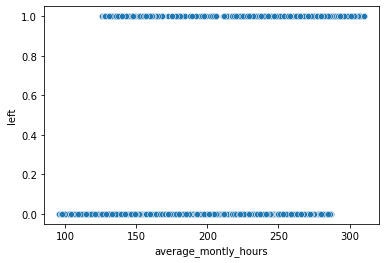

In [ ]:
# Creating a plot as needed
sns.scatterplot(data=df1, x='average_montly_hours', y='left')

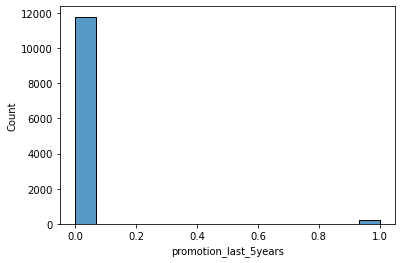

In [ ]:
# Creating a plot as needed
sns.histplot(df1['promotion_last_5years'])

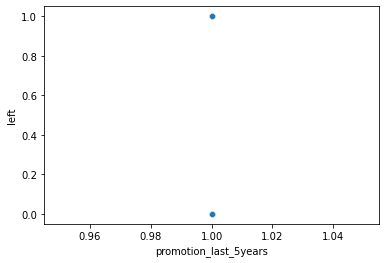

In [ ]:
sns.scatterplot(data=df1[df1['promotion_last_5years']==1], x = 'promotion_last_5years', y='left')

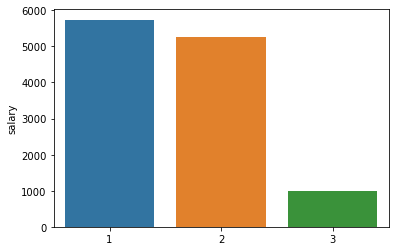

In [ ]:
sns.barplot(y = df1['salary'].value_counts(), x = df1['salary'].unique())


In [ ]:
df1.groupby('department')['left'].count().sort_values()

department
management      436
hr              601
accounting      621
marketing       673
product_mng     686
RandD           694
IT              976
support        1821
technical      2244
sales          3239
Name: left, dtype: int64

### Insights

+ The range in `average_montly_hours` is 200 hours, which is very high, indicating extreme distribution in working hours between employees.
+ `average_montly_hours` seems to be correlated with the `left` variable, where employees who work more than 280 hours tend to leave more and vice versa for those who work less than 125 hours.
+ 98.3% of employees didn't receive a promotion in the last 5 years, but this doesn't seem to have an effect on leaving the company.
+ Most of the employees have low-medium salary while a lower percentage has high salaries.
+ Most of the employees who left are from the `sales`, `technical`, and `support` departments, respectively.

# paCe: Construct Stage
- Determining which models are most appropriate
- Constructing the model
- Confirming model assumptions
- Evaluating model results to determine how well our model fits the data

In [ ]:
#Deleting Outliers
df = df[df['tenure']<=5.5]

## Recalling model assumptions

**Logistic Regression model assumptions**
- Outcome variable is categorical
- Observations are independent of each other
- No severe multicollinearity among X variables
- No extreme outliers
- Linear relationship between each X variable and the logit of the outcome variable
- Sufficiently large sample size

1. The data classes are unequally represented where 82% of employees in the dataset retained and only 18% actually left the company. Also, there are outliers in the `tenure` column that need to be handled since the logistic regression model is sensitive to data.
2. All the features in the dataset were kept as independent variables since this would increase the model score, even though this will increase its complexity as well.
3. All the assumptions were met.
4. The model fit of the data is fairly well regarding the project goals.
5. There is room for improvement for the model, especially by doing feature engineering and/or data resampling to represent both classes equally. Further, we can use tree-based models for better scores.
6. I think the model could improve the ethical policies of the company for treating its employees by motivating them and preventing them from burning out. Even though, we should keep in mind the effect of errors in predictions mentioned above.

## Step 3. Model Building, Step 4. Results and Evaluation
- Fitting a model that predicts the outcome variable using two or more independent variables
- Checking model assumptions
- Evaluating model results

### Identifying the type of prediction task.

> This is a binary prediction task where we want to identify if an employee has left (1) or stayed (0) in the company.

### Identifying the types of models most appropriate for this task.

> Logistic regression and tree-based models (e.g., decision tree, random forest, and xgboost).

### Modeling

We'll add as many cells as we need to conduct the modeling process.

In [ ]:
df.groupby('salary')['left'].count()

salary
1    5429
2    4854
3     884
Name: left, dtype: int64

In [ ]:
df.dtypes

satisfaction_level        float64
last_evaluation           float64
n_projects                  int64
average_montly_hours        int64
tenure                      int64
work_accident               int64
left                        int64
promotion_last_5years       int64
salary                      int64
department_RandD            int64
department_accounting       int64
department_hr               int64
department_management       int64
department_marketing        int64
department_product_mng      int64
department_sales            int64
department_support          int64
department_technical        int64
dtype: object

In [ ]:
y = df['left']
x = df.drop('left', axis=1)
x_test, x_train, y_test, y_train = train_test_split(x,y,stratify=y, test_size=0.2, random_state=42)
clf = LogisticRegression(solver='liblinear')
model = clf.fit(x_train, y_train)
y_pred = model.predict(x_test)

# pacE: Execute Stage
- Interpreting model performance and results
- Sharing actionable steps with stakeholders

## Recalling evaluation metrics

- **AUC** is the area under the ROC curve; it's also considered the probability that the model ranks a random positive example more highly than a random negative example.
- **Precision** measures the proportion of data points predicted as True that are actually True, in other words, the proportion of positive predictions that are true positives.
- **Recall** measures the proportion of data points that are predicted as True, out of all the data points that are actually True. In other words, it measures the proportion of positives that are correctly classified.
- **Accuracy** measures the proportion of data points that are correctly classified.
- **F1-score** is an aggregation of precision and recall.

1. The outcome variable is strongly correlated with the features in the dataset, especially with `tenure`.
2. We recommend trying to minimize pressure on employees by restricting the range of average monthly hours, giving promotions to hard workers in the company, and minimizing the gap in salaries between employees.
3. Developing a more accurate tree-based model to enhance predictions.
4. There is room for improvement for the model because we can aim to minimize false negative predictions by modifying the threshold, also by doing feature engineering and/or data resampling to represent both classes equally.
5. Further questions are: Why is the churn rate relatively high in `sales`, `support`, and `technical` departments? Do these folks work more hours while receiving less salary or promotions? Can we adjust our policies on these departments and then generalize the process if it succeeds? Or is it just that the data is biased and contains more representation of these departments?
6. No ethical considerations so far.

## Step 4. Results and Evaluation
- Interpreting model
- Evaluating model performance using metrics
- Preparing results, visualizations, and actionable steps to share with stakeholders

In [ ]:
import sklearn.metrics as metrics
print(metrics.accuracy_score(y_test,y_pred))
print(metrics.precision_score(y_test,y_pred))
print(metrics.recall_score(y_test,y_pred))
print(metrics.f1_score(y_test,y_pred))
print(metrics.roc_auc_score(y_test,y_pred))

0.8316355087876414
0.5007299270072992
0.22790697674418606
0.31324200913242006
0.5909324867565842


In [ ]:
print(metrics.classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.95      0.90      7428
           1       0.50      0.23      0.31      1505

    accuracy                           0.83      8933
   macro avg       0.68      0.59      0.61      8933
weighted avg       0.80      0.83      0.80      8933



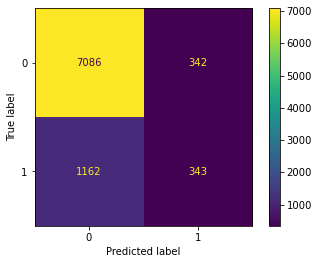

In [ ]:
cm = metrics.confusion_matrix(y_test, y_pred, labels = model.classes_)
metrics.ConfusionMatrixDisplay(confusion_matrix = cm, display_labels= model.classes_).plot(values_format='')
plt.show()

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16]),
 <a list of 17 Text major ticklabel objects>)

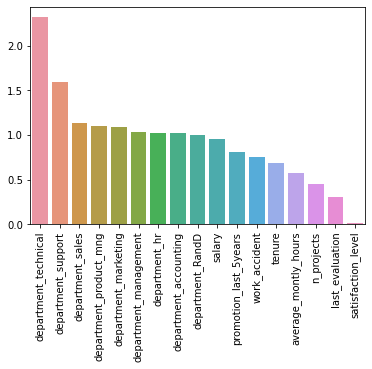

In [ ]:
coef = pd.Series(index = x_train.columns, data = sorted(abs(np.exp(model.coef_[0])))).sort_values(ascending=False)
sns.barplot(x=coef.index, y=coef.values)
plt.xticks(rotation=90)

### Summary of model results

+ The model resulted in very good true negative predictions, however, it shows a lot of false negative errors which we're aiming to minimize.
+ It's still better than a random model and clarified the importance of different factors on employee churn tendency.
+ The model achieved 83% accuracy, 80% precision, 83% recall, and 80% f1-score, even though the results would be much lower if we gave more weight to the goal of predicting employees that will leave the company.
+ The most important features for predicting the outcome are `tenure`, `department`, `last_evaluation`, `number of project`, `average monthly hours`, `promotion last 5 years`, and `salary`.

### Conclusion, Recommendations, Next Steps

+ We conclude that the provided model is a good candidate for explaining the effect of features and predicting the outcome variable, and yet, it needs further improvement to minimize false negative errors and predict employee churn before it happens.
+ The model revealed a lot of important insights about the reasons that cause employees to leave the company. Based on this, we recommend that the company modify its policies in a way that minimizes these effects mentioned in the notebook and seeks to increase tenure and fairness between different departments.
+ After we explained the most important factors, our next step could be to develop an XGBoost or Random Forest model to increase the reliability of the predictions.